# Руководство для байесовского ниндзя (от студента Дейва)

Это адаптация и перевод материала с канала [Student Dave](https://www.youtube.com/channel/UCUxiT_SKEUs1oWT6i9P3vPQ).
Так как его сайт не работает, контакта с ним нет, а его материал очень полезный.

## Зачада
Дейв ставит задачу для бейсовского ниндзя. Необходимо с некоторой точностью найти в кустах перепелку. Где перепелка до опыта не известно, но перепелка дает N криков. По крику с заданой дисперсией можно определить её положение в кустах.

Благодаря теореме Байеса удается по N крикам скорректировать плотность вероятности от равномерного распределения в начале до нормального с очень мелой дисперсией в конце N опытов.

Пример показывает аллгортим итерративного байесовского фильтра.

## Решение

### Входные данные

Опредлеение по крику задано двумерным каусовым распределением с дисперсиями по x, y равное двум.
Но правльно для многомерных с. в. использовать понятие ковариационной матрицы.
\begin{equation}
K = \begin{bmatrix}
\sigma_x^2   & 0         \\
0            & \sigma_y^2
\end{bmatrix} = \begin{bmatrix}
4 & 0 \\
0 & 4
\end{bmatrix}
\end{equation}

In [1]:
# %matplotlib notebook
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt
from math import *
from numpy import linalg as la
from matplotlib.animation import FuncAnimation
import pandas as pd

# written by StudentDave
# for licensing and usage questions
# email scienceguy5000@gmail.com
# recursive bayesian estimation example:
# adapted from Michael A. Goodrich
# 3 Sept 2004, CS 470
# Ported to python rahmaevao@gmil.com 2020

"""
Перепел кричит N раз, и для каждого крика ниндзя слышит перепела в каком-то месте.
Ошибка в оценке того, где находится крик, будет определяться как гауссовская,
где фактически находится перепел со стандартным отклонением 2.
"""

N = 100  # Number of squawks (experiences)
quail = [3, 5] # where the quail is hiding

# Ковариационная матрица измерений
K=[[2**2, 0    ],
   [0,     2**2]]

#squawks = np.array([sd * np.random.randn(N) + quail[0], sd * np.random.randn(N) + quail[1]])
squawks = []
for i in range(N):
    x = K[0][0] * np.random.randn() + quail[0]
    y = K[1][1] * np.random.randn() + quail[1]
    squawks.append([x, y])
squawks = np.array(squawks)    

fig, ax = plt.subplots() 
ax.scatter([quail[0]], [quail[1]],  c='red', alpha=1, edgecolors='none', s=200, label = "Там где сидит перепелка на самом деле")

ax.set(xlim=(0, 10), ylim=(0, 8))
ax.set_title("Расположение перепела и опредление его положения по звуку")
ax.set_xlabel("x")
ax.set_ylabel("y")

sc = ax.scatter(squawks[0], squawks[1], label = "Измеренное положение перепелки")

def animate(i):
    storage = []
    for j in range(range(1, N)[i-1]):
        storage.append(squawks[j])
    sc.set_offsets(storage)
    return sc

anim = FuncAnimation(fig, animate, frames=N, interval=80, blit=False)
ax.legend(loc='lower right')

plt.show()
# anim.save('top_view.gif', writer='imagemagick')

<Figure size 640x480 with 1 Axes>

На график выше виден сам перепел и наше измрение о нем по его крикам.

Теперь строим поверхность - вероятность нахождения перепела в кадрате от 2 до 4 по иксу и от 4 до 6 по игреку (куст). Распределение равномерное.

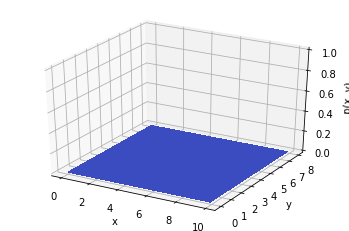

In [2]:
%matplotlib inline
# До опыта (априори) веротность нахождения перепела равномерна
search_area_x = np.arange(0, 10, 0.1) # Область поиска
search_area_y = np.arange(0, 8, 0.1) # Область поиска
prior=np.ones((len(search_area_y),len(search_area_x))) # Initialize all one --> uniform prior

prior=prior/np.sum(np.sum(prior))

fig1 = plt.figure()
ax1 = fig1.gca(projection='3d')
ax1.set_zlim(0, 1)

s_x, s_y = np.meshgrid(search_area_x, search_area_y)
# Plot the surface.
ax1.plot_surface(s_x, s_y, prior, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('p(x, y)')
plt.show()

### Байесовская итерративная оценка

До опыта (априори) вероятность того, что перепелка будет в любом месте кустов одинакова. Априорное распределение равномерное.
Теорема Байеса позволяет уточнять распределение по результатам опыта.
Для корректировки распределения (изначально равномерного) до высокоточного (после $ N $ измерений) необходимо воспользоваться формулой Байеса для непрерывных случайных величин:

\begin{equation}
f_{apost}(X) = \frac{f_{apr}(X) \cdot  f_{mes}(Y)}{\int f_{apr}(X) \cdot  f_{mes}(X) dX}
\end{equation}

где $ X $ - вектор-столбец-перменная вида $\begin{pmatrix} x\\ y\end{pmatrix}$;

$ f_{apost}(X) $ - уточненное распределение;

$ f_{apr}(X) $ - распределение известное до опыта;

$ f_{mes}(X) $ - распределение модели измерения.

Дисперсия распределения модели измерения известна ниндзя заранее. За математическое ожидание примнимается точка пространства, а за случайную величину приравниваем к замеру (вероятность гипотезы о том, что в этой точке пространства сидит перепелка при получении замера):

\begin{equation}
f_{mes}(X) = \frac{1}{(2\pi)^2 detK} e^{0.5 (Y-X)^T K^{-1} (Y-X)}, 
\end{equation}
где $K$ - ковариационная матрица;
$Y$ - результат замера вида  $\begin{pmatrix} x\\ y\end{pmatrix}$;


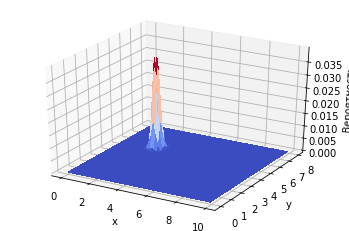

In [3]:
a, b = prior.shape
size = a * b
prior = prior.reshape(size)
search_area_x = s_x.reshape(size)
search_area_y = s_y.reshape(size)
search_area = []
for i in range(len(search_area_y)):
    search_area.append([search_area_x[i], search_area_y[i]])
search_area = np.array(search_area)
        
fig1 = plt.figure()
ax2 = fig1.gca(projection='3d')

def pdf2d(x, mu, k):
    xT = (x - mu).transpose()
    mul1 = np.dot(xT, la.inv(K))
    mul2 = np.dot(mul1, x - mu)
    return 1/(2*pi*sqrt(la.det(K))) * exp(-(1/2) * mul2)

posteriors = [prior]
for squawk in squawks:
    prior = posteriors[len(posteriors)-1]
    posterior = np.array(list(map(lambda exp_v, prior: pdf2d(x = squawk, mu=exp_v, k=K) * prior, search_area, prior)))
    posterior=posterior/np.sum(posterior)
    posteriors.append(posterior)
    
posterior = posterior.reshape(a, b)

surf = ax2.plot_surface(s_x, s_y, posterior, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Вероятность')
plt.show()

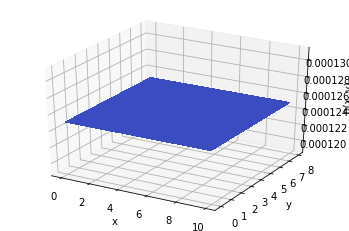

In [4]:
import matplotlib.animation as animation

fig2 = plt.figure()
ax3 = fig2.gca(projection='3d')


plot = ax3.plot_surface(s_x, s_y, posterior, cmap=cm.coolwarm, linewidth=0, antialiased=False)

def animate(i):
    ax3.clear()
    posterior = posteriors[i].reshape(a, b)
    plot = ax3.plot_surface(s_x, s_y, posterior, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_zlabel('p(x, y)')
    return plot,

pam_ani = animation.FuncAnimation(fig2, animate, frames=N, interval=120, blit=False)
pam_ani.save('posteriors2.gif', writer='imagemagick')
